# Two-qubit RY sensing: manual angle sweep & optimization path

This tutorial mirrors the single-photon **1-qubit** tutorial, but with **two qubits**, each carrying a
single trainable `RY` gate in the setup (encoding) and decoding circuits. We:

1. build a two-qubit transient single-photon detection experiment,
2. optimize the four `RY` angles just like the 1-qubit case,
3. **skip the prebuilt `experiment.sweep`** and instead run a *manual*, fully parametric sweep over the
   two `RY` angles acting on **the first qubit** (the setup angle and the decoding angle),
4. overlay the optimizer's trajectory through those two angles on top of the swept landscape.

The manual sweep is a plain nested loop, so you can change the ranges, resolution and averaging by
editing a few variables in the sweep-configuration block.

In [23]:
from qsopt import *
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")
print(f"JAX backend: {jax.default_backend()}")
devices = jax.devices()
print(f"JAX devices: {devices}")
print(f"JAX GPU available: {any(d.platform == 'gpu' for d in devices)}")

JAX version: 0.9.2
QuTiP version: 5.2.2
JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
JAX GPU available: False


## Define experimental parameters

Two qubits are dispersively coupled to the **same** cavity, each with its own coupling `chi`. Giving the two qubits *different* `chi` makes the first-qubit angle landscape non-trivial (the two qubits are not interchangeable).

In [ ]:
sigma = 1
k = 15 * sigma

from jax.scipy.special import erfc

def pulse(t, **kwargs):
    """
    Time-dependent coupling function for input cavity transparency.

    Args:
        t: float or JAX array, time variable
        **kwargs: Dictionary containing 'sigma' parameter (pulse bandwidth)

    Returns:
        JAX array: Normalized coupling strength g(t)
    """
    sigma = kwargs.get("sigma", 1.0)
    # exp(-x^2)/erfc(x) is a numerical 0/0 for large x (both underflow) -> NaN. Clamp |x|<=8 so the
    # coupling stays finite far past the pulse without changing anything in the physical region.
    dx = jnp.clip(sigma * t, -8.0, 8.0)
    coupling = jnp.sqrt(2 * sigma / jnp.sqrt(jnp.pi) * jnp.exp(-(dx**2)) / erfc(dx))
    return jnp.array(coupling, float)

# Two dispersive couplings: one per qubit, both to cavity 0, with different chi so the qubits differ.
interactions = [
    Interaction(interaction_type=InteractionType.DISPERSIVE,
                subsystem1=('cavity', 0), subsystem2=('qubit', 0),
                parameters={'chi': 0.5 * k}),
    Interaction(interaction_type=InteractionType.DISPERSIVE,
                subsystem1=('cavity', 0), subsystem2=('qubit', 1),
                parameters={'chi': 0.5 * k}),
    Interaction(interaction_type=InteractionType.XX,
                subsystem1=('qubit', 0), subsystem2=('qubit', 1),
                parameters={'chi': 0.01}),
]

# Two-qubit physical model
physical_model = PhysicalModel(
    perturbation_type='transient',
    n_cavities=1,
    n_fields=1,
    n_qubits=2,
    cavity_levels=2,
    field_levels=2,
    qubit_levels=2,
    interactions=interactions,
)

# Noise model (per-qubit rates broadcast automatically)
noise = NoiseModel(depolarizing=0.005, dephasing=0.005, relaxation=0.005)

# Time protocol
custom_times = TimeProtocol(
    t_simulation_start=-6,
    n_measurements=4,
    time_interval=4,
    random_measurements_offset=True,
    noisy_simulation_start=False,
)

config_set = [
    SystemConfiguration(
        name='no interaction',
        init_field_states={0: SubsystemState(State.FOCK, {'n': 0})},
        is_ground=True),
    SystemConfiguration(
        name='with interaction',
        init_field_states={0: SubsystemState(State.FOCK, {'n': 1})},
        interactions=[
            Interaction(interaction_type=InteractionType.INPUT_OUTPUT,
                        subsystem1=('cavity', 0), subsystem2=('field', 0),
                        parameters={'gamma': 1, 'kappa': k, 'sigma': sigma},
                        time_modulation=pulse),
        ]),
]

exp_parameters = ExperimentalParameters(
    physical_model=physical_model,
    noise_model=noise,
    time_protocol=custom_times,
    configuration_set=config_set,
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Cavities: 1   levels [2]
  Fields:   1   levels [2]
  Qubits:   2   levels [2, 2]
  Total dimension: 16

PHYSICAL MODEL
  Perturbation type:    transient
  Interactions:         9 interaction(s)
  Static interactions:
    dispersive(cavity0-qubit0): chi=7.5
    dispersive(cavity0-qubit1): chi=7.5
    sx-sx(qubit0-qubit1): chi=0.01
    depolarizing(qubit0): depolarizing=0.005
    dephasing(qubit0): dephasing=0.005
    relaxation(qubit0): relaxation=0.005
    depolarizing(qubit1): depolarizing=0.005
    dephasing(qubit1): dephasing=0.005
    relaxation(qubit1): relaxation=0.005

TIME PROTOCOL
  Start time:            -6.0000
  Mode:                 Interval-based
  Time interval:          4.0000
  Number of measurements:      4
  Computed times:       [-2.0, 2.0, 6.0, 10.0]
  Collective offset:    off
  Per-measurement jitter: none
  Noisy simulation start: off
  Measurement window:   None (uniform weights)

NOISE MODEL
  Depolarizing rate:    [0.005, 0.005]
  Dephasi

## Define quantum circuits

A single `RY` per qubit in each circuit &mdash; four trainable angles in total. The parameter order is `[qubit 0, qubit 1]` inside each circuit, and the optimizer's flat vector is `[setup_q0, setup_q1, decode_q0, decode_q1]`.

In [25]:
from qsopt.core.circuit import create_ry_circuit

initial_circuit = create_ry_circuit(n_qubits=2, theta_values=[np.pi/2, np.pi/2])
final_circuit = create_ry_circuit(n_qubits=2, theta_values=[-np.pi/2, -np.pi/2])

print(f"Setup circuit parameters:    {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Decoding circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Setup circuit parameters:    [Array(1.57079633, dtype=float64), Array(1.57079633, dtype=float64)]
QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=1.571)
  1: RY[1](param=1.571)
Decoding circuit parameters: [Array(-1.57079633, dtype=float64), Array(-1.57079633, dtype=float64)]
QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=-1.571)
  1: RY[1](param=-1.571)


## Define the experiment

The detection metric maximises the computational distance between the *with-interaction* and *no-interaction* measurement outcomes &mdash; the same criterion used in the 1-qubit tutorial, here on a 2-qubit readout.

In [26]:
detection_metric = DetectionMetric(
    n_cavities=1,
    n_fields=1,
    n_qubits=2,
    config_names=['with interaction', 'no interaction'],
    detection_criterion='max computational distance',
    perturbation_type=physical_model.perturbation_type,
)
print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric,
)


DetectionMetric:
maximize computational distance
softmax aggregation, transient



In [27]:
results = experiment.run_simulation(batch_size=16)
print(results)

MODE: Single Simulation
  Experiment metadata:  absent
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
        param_1: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
  Detection Measures:
     no interaction   : 0.000000
     with interaction : 0.000000
  Objective:
     Metric:     0.732104
     Validation: 0.732104


## Run the optimization

Gradient descent over the four `RY` angles, exactly as in the 1-qubit tutorial. We pass an explicit callback so its parameter history survives for the trajectory plot at the end.

In [ ]:
import optax

# Explicit callback so this history is not overwritten by later evaluations.
history = OptimizationCallback(save_every=1, save_best=True)

history = experiment.optimize_rotations(
    initial_values=[np.pi/2 + 0.4, np.pi/2,  -np.pi/2 - 0.7, -np.pi/2],  # [setup_q0, setup_q1, decode_q0, decode_q1]
    num_steps=1000,
    verbose=True,
    verbose_step=25,
    batch_size=16,
    tolerance=1e-7,
    callback=history,
    optimizer=optax.sgd(learning_rate=0.5),
    normalize_theta_step=True,
    anneal_tolerances=False,
)

Configuration:
    Max iterations: 1000
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric:
maximize computational distance
softmax aggregation, transient
    Trainable parameters: 4 (2 initial circuit + 2 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.971  rad (112.9°)
        param1.  setup_RY[1]  = 1.571  rad (90.0°)
        param2.  reset_RY[0]  = -2.271 rad (-130.1°)
        param3.  reset_RY[1]  = -1.571 rad (-90.0°)
Step  setup0_RY[0]   setup1_RY[1]   reset0_RY[0]   reset1_RY[1]   Metric      Validation  Grad Norm   Time
---------------------------------------------------------------------------------------------------------------
0     1.970796       1.570796       -2.270796      -1.570796      0.208097    0.664960    5.57e-02    00h00m15s
1     1.978295       1.570441       -2.243989      -1.570016      0.209967    0.670523    5.12e-02    00h00m17s
2     1.984031       1.570089       -2.219028      -1.569256      0.211450

In [35]:
# Free JAX memory after optimization
jax.clear_caches()
import gc; gc.collect()

1436

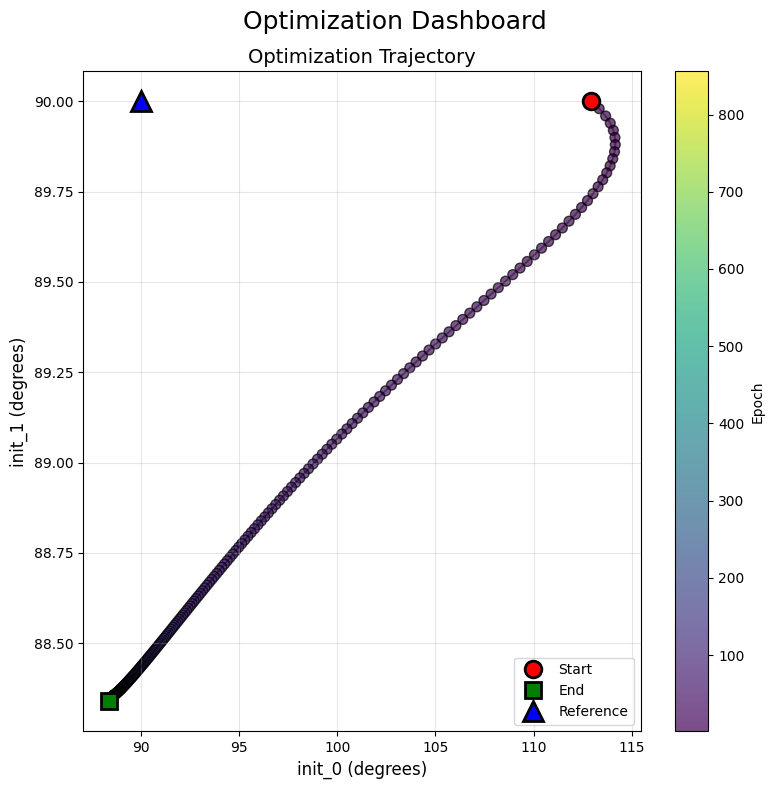

In [36]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create optimization path graph
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_metric=False,
    show_gradients=False,
    show_parameters=False,
    show_detection_measures=False,
    show_trajectory=True,
    show_confusion_matrix=False,
    show_mixed_column=False,
    figsize=(8,8),
    save_path='results/temp_path_for_paper.pdf'  # Save to file
)

plt.show()

Build the deployable detection protocol at the best parameters (also loads them back onto the circuits).

In [37]:
history = experiment.make_protocol(callback=history, batch_size=16)
history.save(filepath='2qb_sweeped_path')
print(history)

MODE: Optimization
     Total iterations: 856
     Best epoch:        856
     Converged: True
     Final gradient norm: 7.488116e-08
  Experiment metadata:  present (use print_metadata())
  Best Parameters:
     Initial circuit:
        param_0: 1.541799 rad (88.34°)
        param_1: 1.541799 rad (88.34°)
     Final circuit:
        param_0: -1.533830 rad (-87.88°)
        param_1: -1.533830 rad (-87.88°)
  Detection Measures:
     no interaction   : 0.000000
     with interaction : 0.000000
  Objective:
     Metric:     0.658981
     Validation: 0.732471
  Detection Protocol (states classified per configuration):
     no interaction: ['00', '01', '10']
     with interaction: ['11']
  False signal (joint, per configuration):
     no interaction: 0.0053
     with interaction: 0.0000
  Confusion Matrix (rows: true, cols: predicted):
                           no interaction  with interaction             mixed
         no interaction            0.9947            0.0053            0.0000


## Manual parametric sweep over the first-qubit angles

Instead of `experiment.sweep`, we sweep **by hand** over the two `RY` angles acting on **qubit 0**:
the *setup* angle and the *decoding* angle. For every point on the grid we set those two angles on the
circuits and call `run_simulation`, reading back the detection metric.

The two qubit-1 angles are held **fixed at their optimized values**, so the 2-D map is a slice of the
full 4-D landscape through the optimum. Everything below is a plain nested loop &mdash; change the ranges,
resolution and averaging in the configuration block to taste.

> This is the heavy cell: it runs `n_setup * n_reset` simulations. Start coarse and refine.

In [38]:
# Qubit-1 angles are frozen at their optimized values while we sweep qubit 0.
best_init, best_final = history.get_best_trainable_params()
fixed_setup_q1 = float(best_init[1])
fixed_reset_q1 = float(best_final[1])
print(f"Frozen qubit-1 angles -> setup: {fixed_setup_q1:+.4f} rad, decoding: {fixed_reset_q1:+.4f} rad")

# ================= SWEEP CONFIGURATION (edit these) =================
n_setup = 15                    # grid resolution along the setup angle (qubit 0)
n_reset = 15                    # grid resolution along the decoding angle (qubit 0)
setup_range = (np.pi/2 -np.pi/6, np.pi/2 + np.pi/6)   # setup angle range   (rad)
reset_range = (-np.pi/2 +np.pi/6, -np.pi/2 - np.pi/6)   # decoding angle range (rad)
sweep_batch_size = 4            # timing realizations averaged per grid point
# ===================================================================

setup_grid = np.linspace(*setup_range, n_setup)
reset_grid = np.linspace(*reset_range, n_reset)


def manual_angle_sweep(experiment, setup_grid, reset_grid,
                       fixed_setup_q1, fixed_reset_q1, batch_size):
    """Sweep the first-qubit setup/decoding RY angles, returning the detection-metric grid.

    Args:
        experiment: the Experiment whose circuits are mutated in place.
        setup_grid (np.ndarray): setup-angle values for qubit 0 (x axis).
        reset_grid (np.ndarray): decoding-angle values for qubit 0 (y axis).
        fixed_setup_q1 (float): frozen setup angle for qubit 1.
        fixed_reset_q1 (float): frozen decoding angle for qubit 1.
        batch_size (int): timing realizations averaged per grid point.

    Returns:
        np.ndarray: metric grid of shape (len(reset_grid), len(setup_grid)).
    """
    metric_grid = np.zeros((len(reset_grid), len(setup_grid)))
    for i, r0 in enumerate(reset_grid):
        for j, s0 in enumerate(setup_grid):
            experiment.initial_circuit.set_trainable_parameters([float(s0), fixed_setup_q1])
            experiment.final_circuit.set_trainable_parameters([float(r0), fixed_reset_q1])
            cb = experiment.run_simulation(batch_size=batch_size)
            metric_grid[i, j] = cb.history['metric'][0]
        print(f"  decoding row {i + 1}/{len(reset_grid)} done")
    return metric_grid


metric_grid = manual_angle_sweep(
    experiment, setup_grid, reset_grid, fixed_setup_q1, fixed_reset_q1, sweep_batch_size)

# Restore the optimized parameters onto the circuits after the sweep.
experiment.initial_circuit.set_trainable_parameters(list(best_init))
experiment.final_circuit.set_trainable_parameters(list(best_final))

bi, bj = np.unravel_index(np.argmax(metric_grid), metric_grid.shape)
print(f"Sweep maximum {metric_grid[bi, bj]:.4f} at "
      f"setup={setup_grid[bj]:+.3f} rad, decoding={reset_grid[bi]:+.3f} rad")

Frozen qubit-1 angles -> setup: +1.5418 rad, decoding: -1.5338 rad
  decoding row 1/15 done
  decoding row 2/15 done
  decoding row 3/15 done
  decoding row 4/15 done
  decoding row 5/15 done
  decoding row 6/15 done
  decoding row 7/15 done
  decoding row 8/15 done
  decoding row 9/15 done
  decoding row 10/15 done
  decoding row 11/15 done
  decoding row 12/15 done
  decoding row 13/15 done
  decoding row 14/15 done
  decoding row 15/15 done
Sweep maximum 0.7323 at setup=+1.571 rad, decoding=-1.571 rad


## Visualize the optimization path over the swept landscape

We extract the optimizer's trajectory through the two first-qubit angles from the callback history and
draw it on top of the manually swept metric map. The path is a projection of the full 4-D trajectory onto
the qubit-0 plane, over a landscape sliced at the optimized qubit-1 angles &mdash; so the end of the path lands
near (but not exactly on) the swept maximum whenever the qubit-1 angles moved during training.

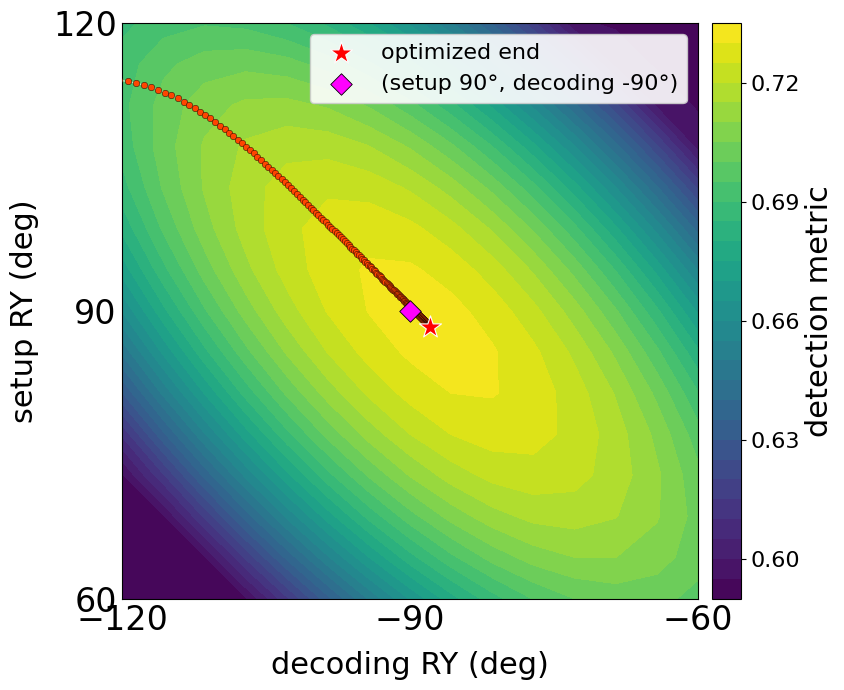

In [45]:
# ============ PLOT OPTIONS (edit these) ============
show_sweep_max = False   # toggle the 'sweep maximum' marker
# ===================================================

from matplotlib.ticker import MultipleLocator, MaxNLocator, FormatStrFormatter

# First-qubit angle trajectory: p = (initial_params, final_params); index [0] = qubit 0.
tp = history.history['trainable_params']
setup_q0_path = np.array([p[0][0] for p in tp])
reset_q0_path = np.array([p[1][0] for p in tp])

# Axes are drawn in degrees; the swept data lives in radians.
setup_grid_deg = np.degrees(setup_grid)
reset_grid_deg = np.degrees(reset_grid)
setup_path_deg = np.degrees(setup_q0_path)
reset_path_deg = np.degrees(reset_q0_path)

fig, ax = plt.subplots(figsize=(8.5, 7))

# Swept detection-metric landscape (x = decoding, y = setup -> transpose the grid).
cf = ax.contourf(reset_grid_deg, setup_grid_deg, metric_grid.T, levels=30, cmap='viridis')
cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label('detection metric', fontsize=22)   # -> 22
cbar.locator = MaxNLocator(nbins=5)
cbar.formatter = FormatStrFormatter('%.2f')
cbar.update_ticks()
cbar.ax.tick_params(labelsize=16)                 # -> 16

# Optimizer trajectory (x = decoding, y = setup), constant red-orange at every epoch.
ax.plot(reset_path_deg, setup_path_deg, '-', color='white', lw=1.0, alpha=0.6, zorder=2)
ax.scatter(reset_path_deg, setup_path_deg, color='orangered',
           s=22, zorder=3, edgecolors='k', linewidths=0.3)

# Start, end and (optional) sweep-maximum markers.
ax.scatter(reset_path_deg[0], setup_path_deg[0], marker='o', s=150, facecolors='none',
           edgecolors='white', lw=2, zorder=4)
ax.scatter(reset_path_deg[-1], setup_path_deg[-1], marker='*', s=280, color='red',
           edgecolors='white', lw=0.8, zorder=4, label='optimized end')
if show_sweep_max:
    ax.scatter(np.degrees(reset_grid[bi]), np.degrees(setup_grid[bj]), marker='X', s=150,
               color='cyan', edgecolors='k', lw=0.6, zorder=4, label='sweep maximum')

# Single reference point at setup=90, decoding=-90  (x = decoding = -90, y = setup = 90).
ax.scatter(-90, 90, marker='D', s=120, color='magenta',
           edgecolors='k', lw=0.6, zorder=5, label='(setup 90°, decoding -90°)')

# Ticks every 30 degrees on both axes.
ax.xaxis.set_major_locator(MultipleLocator(30))
ax.yaxis.set_major_locator(MultipleLocator(30))

ax.set_xlabel('decoding RY (deg)', fontsize=22, labelpad=10)   # -> 22
ax.set_ylabel('setup RY (deg)', fontsize=22, labelpad=10)      # -> 22
ax.tick_params(axis='both', labelsize=24, pad=4, length=0)     # -> 24
ax.legend(loc='upper right', framealpha=0.9, fontsize=16)      # -> 16

# Show only the swept region (x = decoding, y = setup).
ax.set_xlim(reset_grid_deg.min(), reset_grid_deg.max())
ax.set_ylim(setup_grid_deg.min(), setup_grid_deg.max())
ax.set_box_aspect(1)   # square plotting area

plt.tight_layout()
plt.savefig('results/two_qubit_angle_sweep_path.pdf', bbox_inches='tight')
plt.show()


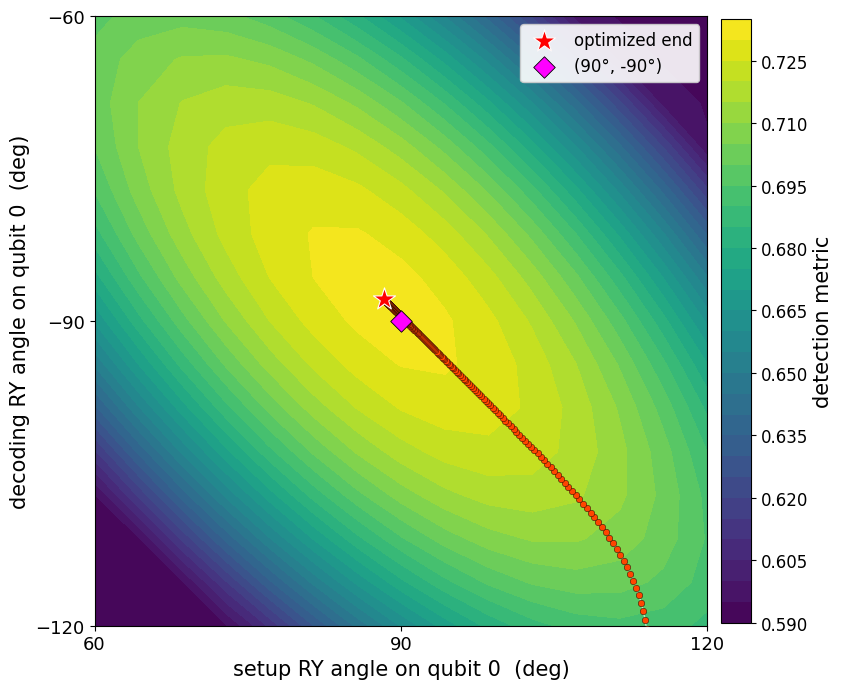

In [42]:
# ============ PLOT OPTIONS (edit these) ============
show_sweep_max = False   # toggle the 'sweep maximum' marker
# ===================================================

from matplotlib.ticker import MultipleLocator

# First-qubit angle trajectory: p = (initial_params, final_params); index [0] = qubit 0.
tp = history.history['trainable_params']
setup_q0_path = np.array([p[0][0] for p in tp])
reset_q0_path = np.array([p[1][0] for p in tp])

# Axes are drawn in degrees; the swept data lives in radians.
setup_grid_deg = np.degrees(setup_grid)
reset_grid_deg = np.degrees(reset_grid)
setup_path_deg = np.degrees(setup_q0_path)
reset_path_deg = np.degrees(reset_q0_path)

fig, ax = plt.subplots(figsize=(8.5, 7))

# Swept detection-metric landscape.
cf = ax.contourf(setup_grid_deg, reset_grid_deg, metric_grid, levels=30, cmap='viridis')
cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label('detection metric', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# Optimizer trajectory, constant red-orange at every epoch.
ax.plot(setup_path_deg, reset_path_deg, '-', color='white', lw=1.0, alpha=0.6, zorder=2)
ax.scatter(setup_path_deg, reset_path_deg, color='orangered',
           s=22, zorder=3, edgecolors='k', linewidths=0.3)

# Start, end and (optional) sweep-maximum markers.
ax.scatter(setup_path_deg[0], reset_path_deg[0], marker='o', s=150, facecolors='none',
           edgecolors='white', lw=2, zorder=4)
ax.scatter(setup_path_deg[-1], reset_path_deg[-1], marker='*', s=280, color='red',
           edgecolors='white', lw=0.8, zorder=4, label='optimized end')
if show_sweep_max:
    ax.scatter(np.degrees(setup_grid[bj]), np.degrees(reset_grid[bi]), marker='X', s=150,
               color='cyan', edgecolors='k', lw=0.6, zorder=4, label='sweep maximum')

# Single reference point at (90, -90) degrees.
ax.scatter(90, -90, marker='D', s=120, color='magenta',
           edgecolors='k', lw=0.6, zorder=5, label='(90°, -90°)')

# Ticks every 30 degrees on both axes.
ax.xaxis.set_major_locator(MultipleLocator(30))
ax.yaxis.set_major_locator(MultipleLocator(30))

ax.set_xlabel('setup RY angle on qubit 0  (deg)', fontsize=15)
ax.set_ylabel('decoding RY angle on qubit 0  (deg)', fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.legend(loc='upper right', framealpha=0.9, fontsize=12)
# Show only the swept region; trajectory points outside it are clipped.
ax.set_xlim(setup_grid_deg.min(), setup_grid_deg.max())
ax.set_ylim(reset_grid_deg.min(), reset_grid_deg.max())
plt.tight_layout()
plt.savefig('results/two_qubit_angle_sweep_path.pdf', bbox_inches='tight')
plt.show()
